<a href="https://colab.research.google.com/github/AFK-Kuntal/MNIST-DigitClassification/blob/main/Digit_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
tf.__version__

'2.20.0'

In [6]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [18]:
def load_data_and_preprocess():
  (X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
  X_train = X_train.astype('float32') / 255.0
  X_test = X_test.astype('float32') / 255.0
  X_train = np.expand_dims(X_train, -1)
  X_test = np.expand_dims(X_test, -1)
  return (X_train, y_train), (X_test, y_test)

In [19]:
(X_train, y_train), (X_test, y_test) = load_data_and_preprocess()

In [20]:
print(type(X_train))
X_train

<class 'numpy.ndarray'>


array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = SEED)

In [30]:
print(f"the shape of the train set is {X_train.shape}")
print(f"the shape of the val set is {X_val.shape}")
print(f"the shape of the test set is {X_test.shape}")

the shape of the train set is (48000, 28, 28, 1)
the shape of the val set is (12000, 28, 28, 1)
the shape of the test set is (10000, 28, 28, 1)


In [35]:
def plot_digits(X, y):
  for i in range(20):
    idx = np.random.randint(0, len(X))
    plt.subplot(4, 5, i + 1)
    plt.imshow(X[i].squeeze(), cmap = 'grey')
    plt.title(f"Digit: {y[i]}")
    plt.axis('off')
    plt.tight_layout()
  plt.show()

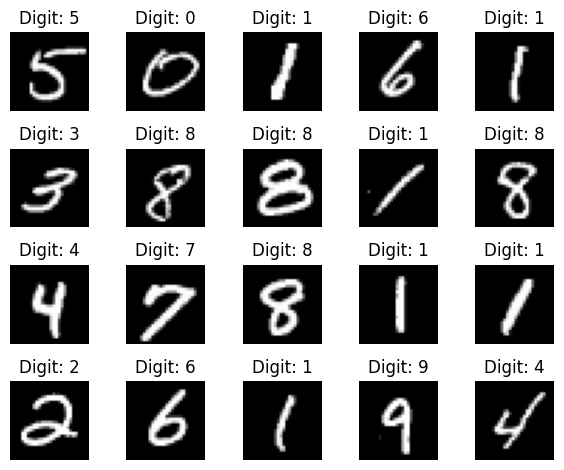

In [36]:
plot_digits(X_train, y_train)

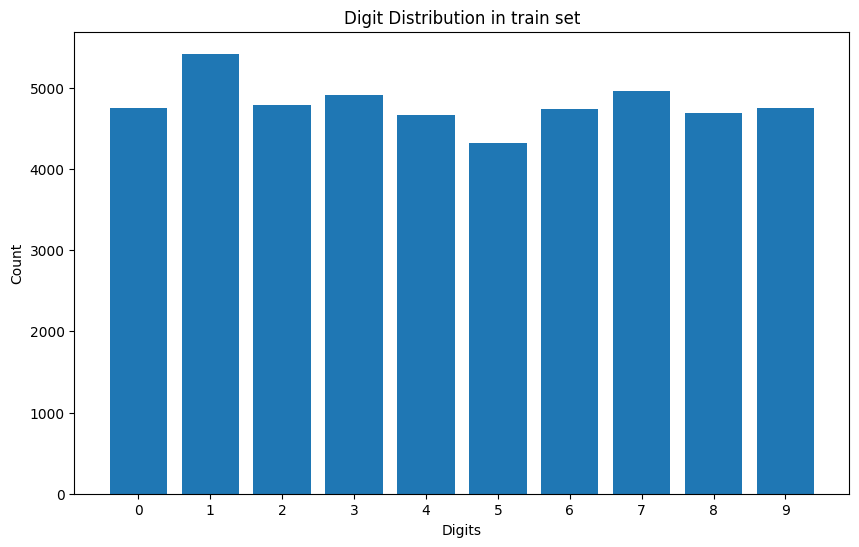

In [44]:
unique_labels, counts = np.unique(y_train, return_counts = True)
plt.figure(figsize = (10, 6))
plt.bar(unique_labels, counts)
plt.xticks(unique_labels)
plt.xlabel("Digits")
plt.ylabel("Count")
plt.title("Digit Distribution in train set")
plt.show()

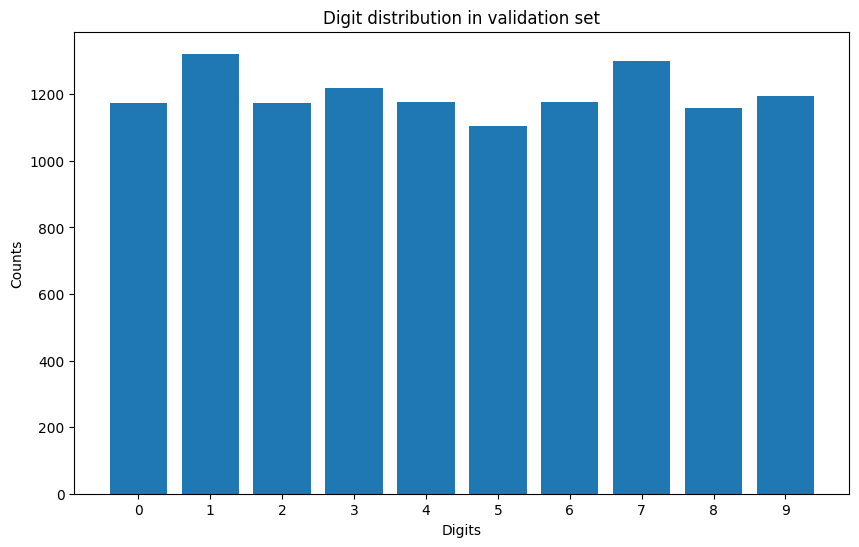

In [46]:
unique_labels_val, counts_val = np.unique(y_val, return_counts = True)
plt.figure(figsize = (10, 6))
plt.bar(unique_labels_val, counts_val)
plt.xticks(unique_labels_val)
plt.xlabel("Digits")
plt.ylabel("Counts")
plt.title("Digit distribution in validation set")
plt.show()